## Start

## Projet de classifcation de cellules sanguignes

Le jeu de données se compose de 17,092 images de cellules individuelles et sans pathologies. 
Les images sont organisées en 8 groupes (dossiers)
- neutrophils
- eosinophils
- basophils
- lymphocytes
- monocytes
- immature granulocytes (promyelocytes, myelocytes, and metamyelocytes)
- erythroblasts
- platelets (or thrombocytes)

Les images sont de dimmensionsb 360 x 363 pixels

Le regroupement des images en différentes catégories a été réalisé par des experts en pathologies cliniques. Les cellules sont issues d'individus sans infections particulières, sans maladies hematologiques ou oncologiques et sans traitement pharmaceutique.

Les données ont été collectées durant 4 ans (de 2015 à 2019)

In [58]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import cv2
from collections import Counter
from glob import glob
import pandas as pd
from sklearn.decomposition import PCA


## Prévisualisation des images : 


In [6]:
DATASET_PATH = "/Users/seeqle/Desktop/Code/DST/DataScienceTest_BloodCellClassification/PBC_dataset_normal_DIB"

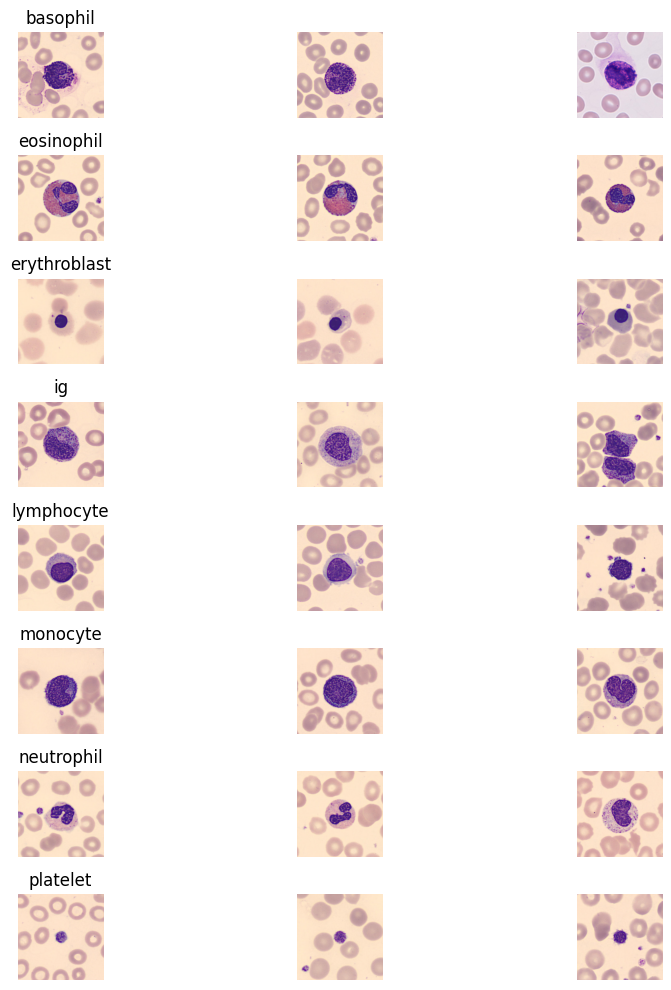

In [77]:
classes = sorted(os.listdir(DATASET_PATH))
class_counts = {cls: len(os.listdir(os.path.join(DATASET_PATH, cls))) for cls in classes}

def plot_sample_images(dataset_path,classes, samples_per_class=3):
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(10, 10))
    for i, cls in enumerate(classes):
        image_files = glob(os.path.join(dataset_path, cls, "*.jpg"))  # Adjust extension if needed
        for j in range(samples_per_class):
            img = cv2.imread(image_files[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(cls)
    plt.tight_layout()
    plt.show()

plot_sample_images(DATASET_PATH, classes)

## Analyse de la distribution des données en fonction des différentes classes 

/var/folders/k5/1lqxpwps1ln_nfp34l8svkv40000gp/T/ipykernel_20689/2605491692.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


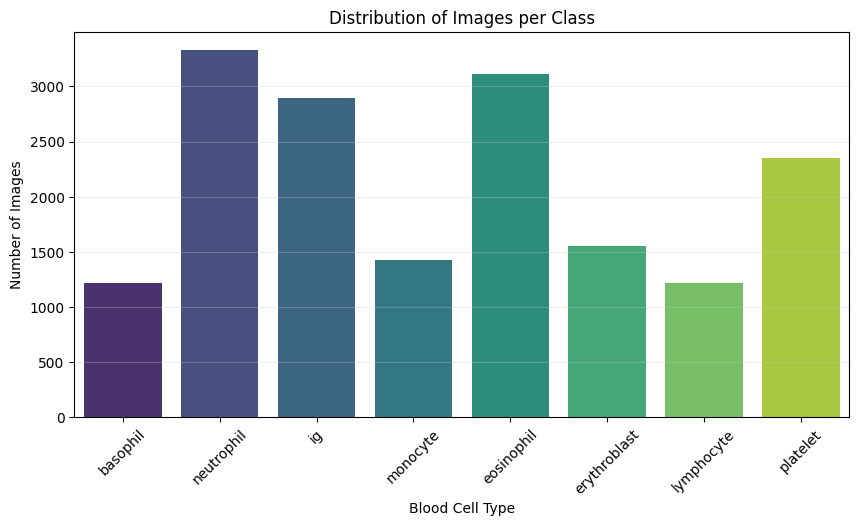

In [78]:

class_counts = {}
for class_name in os.listdir(DATASET_PATH):
    class_folder = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

# Plot distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
plt.xlabel("Blood Cell Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Images per Class")
plt.xticks(rotation=45)
plt.show()

En visualisant la distribution, on remarque que les classes sont desiquilibrées. Une attention particulière devra être considérée lors de l'analyse des résulats du futur modèle. 
Nous aurons alors peut-être recours à un processus de réequilibrage des différenets classes 

## Analyse des couleurs des images 

In [9]:
def extract_pixel_data(image_path):
    # Ouvrir l'image avec PIL
    img = Image.open(image_path)
    
    # Convertir en mode RGB si nécessaire (pour les images en niveaux de gris)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    
    # Récupérer les dimensions de l'image
    width, height = img.size
    
    # Extraire les données des pixels
    pixels = list(img.getdata())
    
    # Créer une liste de dictionnaires avec les coordonnées et les valeurs RGB
    pixel_list = []
    for index, pixel in enumerate(pixels):
        x = index % width
        y = index // width
        pixel_list.append({
            'x': x,
            'y': y,
            'red': pixel[0],
            'green': pixel[1],
            'blue': pixel[2]
        })
    
    # Créer le DataFrame
    df = pd.DataFrame(pixel_list)
    return df

# def visualize_cell_types_distribution(base_dir):
#     """
#     Crée une visualisation claire des distributions RGB pour chaque type de cellule.
    
#     Args:
#         base_dir (str): Chemin vers le répertoire principal contenant les sous-dossiers des types de cellules
#     """
#     cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
#                   'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
#     # Créer une grille de sous-graphiques (4x2)
#     fig, axes = plt.subplots(4, 2, figsize=(20, 24))
#     fig.suptitle('Distribution RGB par type de cellule', fontsize=16, y=0.95)
#     axes = axes.ravel()  # Aplatir le tableau d'axes pour un accès plus facile
    
#     # Couleurs pour les canaux RGB avec une meilleure transparence
#     colors = ['#FF000080', '#00FF0080', '#0000FF80']
#     labels = ['Rouge', 'Vert', 'Bleu']
    
#     for idx, cell_type in enumerate(cell_types):
#         cell_dir = os.path.join(base_dir, cell_type)
#         if not os.path.exists(cell_dir):
#             print(f"Dossier non trouvé pour {cell_type}")
#             continue
            
#         # Récupérer les données RGB
#         all_red, all_green, all_blue = [], [], []
#         image_files = glob(os.path.join(cell_dir, "*.jpg"))
        
#         for img_path in image_files[:30]:
#             df = extract_pixel_data(img_path)
#             all_red.extend(df['red'])
#             all_green.extend(df['green'])
#             all_blue.extend(df['blue'])
        
#         # Échantillonnage pour améliorer les performances
#         sample_size = min(10000, len(all_red))
#         indices = np.random.choice(len(all_red), sample_size, replace=False)
        
#         rgb_data = [
#             np.array(all_red)[indices],
#             np.array(all_green)[indices],
#             np.array(all_blue)[indices]
#         ]
        
#         # Tracer les courbes de densité
#         for color_data, color, label in zip(rgb_data, colors, labels):
#             sns.kdeplot(
#                 data=color_data,
#                 ax=axes[idx],
#                 color=color,
#                 label=label,
#                 fill=True,
#                 alpha=0.3,
#                 linewidth=2
#             )
        
#         axes[idx].set_title(f'Type: {cell_type}')
#         axes[idx].set_xlabel('Valeur de pixel')
#         axes[idx].set_ylabel('Densité')
#         axes[idx].legend()
        
#         # Ajouter des statistiques dans le titre
#         stats_text = f'μ(R)={np.mean(rgb_data[0]):.1f}, μ(G)={np.mean(rgb_data[1]):.1f}, μ(B)={np.mean(rgb_data[2]):.1f}'
#         axes[idx].set_title(f'Type: {cell_type}\n{stats_text}', pad=10)
    
#     plt.tight_layout()
#     plt.show()

In [10]:
def visualize_cell_types_distribution(base_dir):
    """
    Creates a clear visualization of RGB distributions for each cell type with enhanced readability
    and normalized y-axis scale for better comparison across classes.
    
    Args:
        base_dir (str): Path to the main directory containing cell type subdirectories
    """
    cell_types = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                  'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
    # Set the style parameters manually
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.color'] = '#cccccc'
    
    # Create subplot grid (4x2) with increased spacing
    fig, axes = plt.subplots(4, 2, figsize=(20, 24))
    
    # Enhanced main title with bold font and increased spacing
    fig.suptitle('Distribution RGB par type de cellule', 
                 fontsize=20, 
                 y=0.95, 
                 fontweight='bold')
    
    # Flatten the axes array for easier access
    axes = axes.ravel()
    
    # Enhanced color palette with better contrast and visual appeal
    colors = ['#FF6B6B', '#4ECB71', '#4A90E2']  # Softer red, green, blue
    labels = ['Rouge', 'Vert', 'Bleu']
    
    # Lists to store all density values for y-axis normalization
    all_densities = []
    
    # First pass: calculate KDE for all cell types to find global y-axis limits
    for idx, cell_type in enumerate(cell_types):
        cell_dir = os.path.join(base_dir, cell_type)
        if not os.path.exists(cell_dir):
            print(f"Dossier non trouvé pour {cell_type}")
            continue
            
        # Get RGB data
        all_red, all_green, all_blue = [], [], []
        image_files = glob(os.path.join(cell_dir, "*.jpg"))
        
        for img_path in image_files[:30]:
            df = extract_pixel_data(img_path)
            all_red.extend(df['red'])
            all_green.extend(df['green'])
            all_blue.extend(df['blue'])
        
        # Sampling for performance
        sample_size = min(10000, len(all_red))
        indices = np.random.choice(len(all_red), sample_size, replace=False)
        
        rgb_data = [
            np.array(all_red)[indices],
            np.array(all_green)[indices],
            np.array(all_blue)[indices]
        ]
        
        # Calculate KDE for each color channel
        for color_data in rgb_data:
            kde = sns.kdeplot(data=color_data, ax=axes[idx]).get_lines()[-1].get_data()
            all_densities.extend(kde[1])
    
    # Calculate global y-axis limits
    y_max = max(all_densities)
    
    # Second pass: plot with normalized y-axis
    for idx, cell_type in enumerate(cell_types):
        cell_dir = os.path.join(base_dir, cell_type)
        if not os.path.exists(cell_dir):
            continue
            
        # Clear previous plots
        axes[idx].clear()
        
        # Set background color
        axes[idx].set_facecolor('#f8f8f8')
        
        # Get RGB data again
        all_red, all_green, all_blue = [], [], []
        image_files = glob(os.path.join(cell_dir, "*.jpg"))
        
        for img_path in image_files[:30]:
            df = extract_pixel_data(img_path)
            all_red.extend(df['red'])
            all_green.extend(df['green'])
            all_blue.extend(df['blue'])
        
        sample_size = min(10000, len(all_red))
        indices = np.random.choice(len(all_red), sample_size, replace=False)
        
        rgb_data = [
            np.array(all_red)[indices],
            np.array(all_green)[indices],
            np.array(all_blue)[indices]
        ]
        
        # Plot with normalized y-axis
        for color_data, color, label in zip(rgb_data, colors, labels):
            sns.kdeplot(
                data=color_data,
                ax=axes[idx],
                color=color,
                label=label,
                fill=True,
                alpha=0.2,
                linewidth=2.5
            )
        
        # Set y-axis limits
        axes[idx].set_ylim(0, y_max * 1.1)  # Add 10% padding
        
        # Enhanced subplot formatting
        axes[idx].set_xlabel('Valeur de pixel', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Densité', fontsize=12, fontweight='bold')
        axes[idx].tick_params(axis='both', labelsize=10)
        
        # Enhanced legend
        axes[idx].legend(fontsize=10, frameon=True, framealpha=0.9,
                        facecolor='white', edgecolor='gray')
        
        # Calculate statistics
        stats_text = (f'μ(R)={np.mean(rgb_data[0]):.1f}, '
                     f'μ(G)={np.mean(rgb_data[1]):.1f}, '
                     f'μ(B)={np.mean(rgb_data[2]):.1f}')
        
        # Enhanced title
        axes[idx].set_title(f'Type: {cell_type}\n{stats_text}',
                          fontsize=14,
                          fontweight='bold',
                          pad=20)
        
        axes[idx].margins(0.1)
        axes[idx].grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout(h_pad=0.8, w_pad=0.8)
    fig.patch.set_facecolor('white')
    
    plt.show()

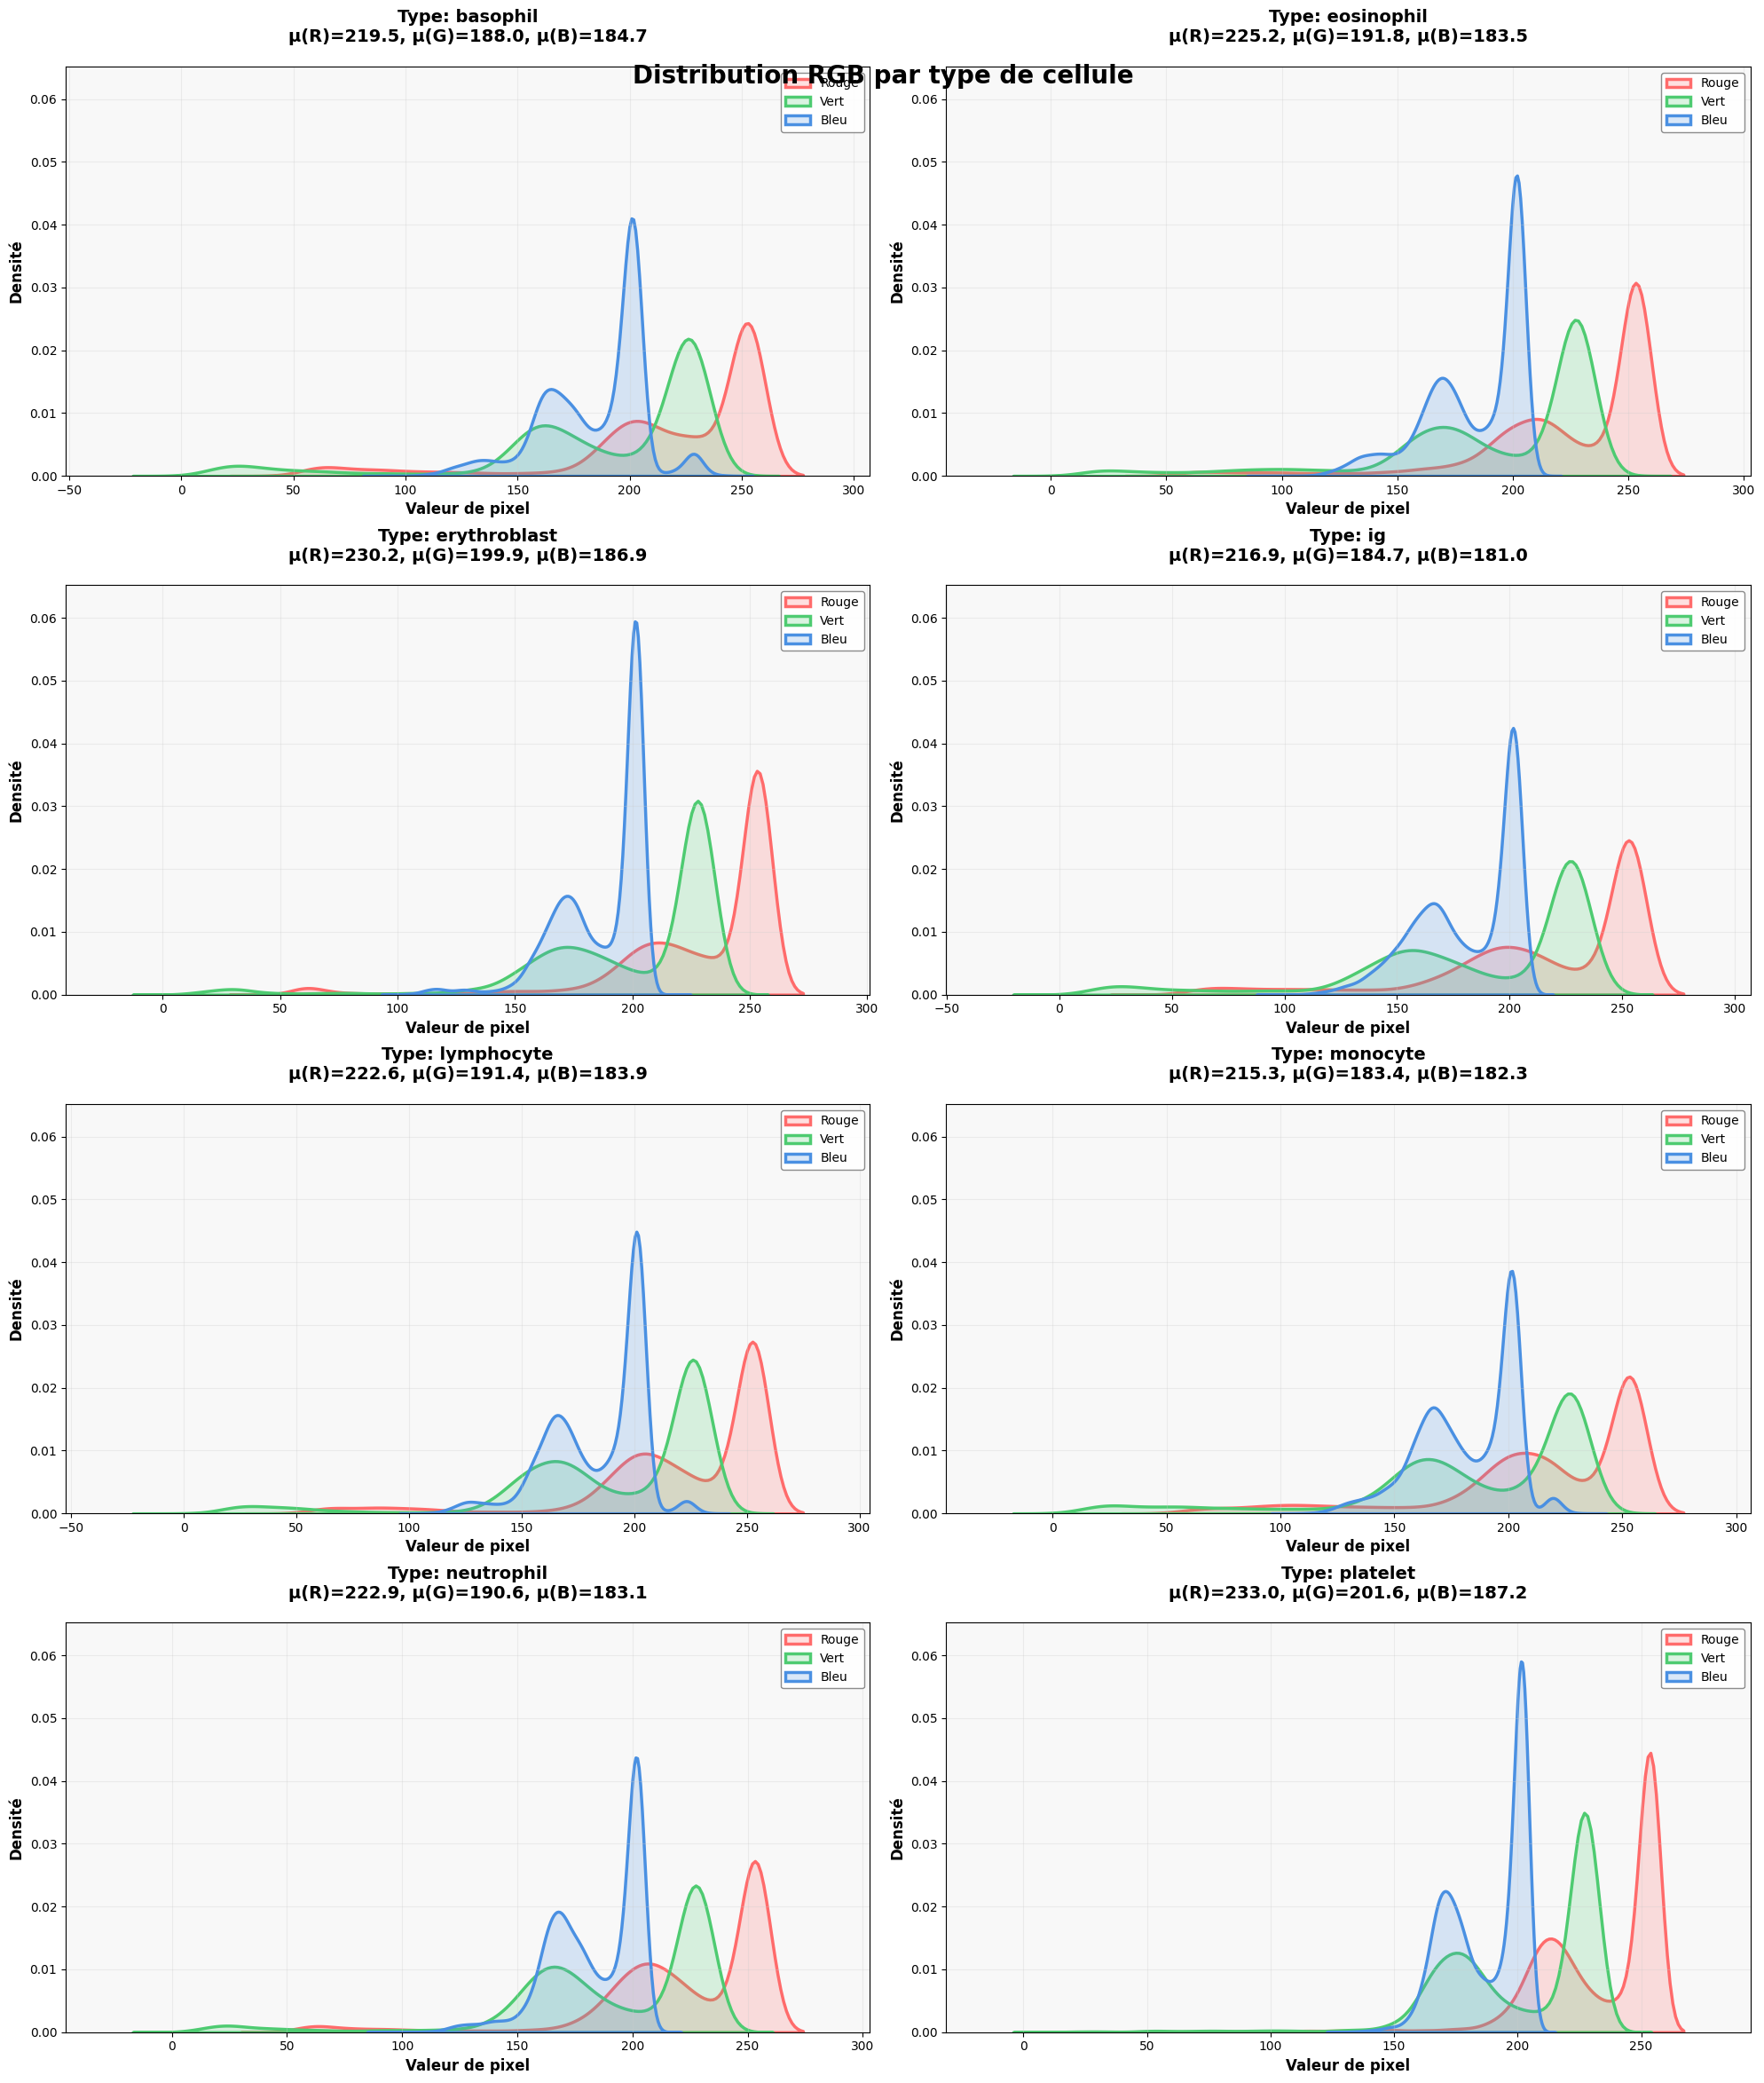

In [79]:
visualize_cell_types_distribution(DATASET_PATH)

Ce graphique représente les histogrames des intensités des couleurs (rouges , vertes, et bleues) pour chaques classes. 
Dans la globalité, les histogrammes paraissent similaires tant ils se ressemblent. 
Les différents pics (d'abords un petit puis un grand) sont assez cohérents avec la prévisualisation que nous avions observé puisque la quantité d'intensité des pixels sont répartis majoritairement en deux parties (la cellule et le fond). 

# PCA sur les nuances de gris 

### Création d'un dataset 

In [80]:
MAX_IMAGES = 100  # On fixe le nombre maximum d'image par classe que l'on souhaite selectionner
image_data = []
labels = []
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path): 
        image_files = os.listdir(class_path)[:MAX_IMAGES] 
        for image_name in image_files:
            image_path = os.path.join(class_path, image_name)
       
            image = Image.open(image_path).convert("L") 
            image = np.array(image).flatten()  

            image_data.append(image)
            labels.append(class_name)
df = pd.DataFrame(image_data)
df.insert(0, "label", labels)  

print("Dataset shape:", df.shape)
df = df.dropna(axis=1, how='any')
print("Dataset shape:", df.shape)


Dataset shape: (800, 135055)
Dataset shape: (800, 129601)


Précision : la méthode dropna va ôter les colonnes qui contiennent au moins une valeur manquante (arg 'any'). 
Les images étant de tailles différentes, ce sont seulement les dernières colonnes qui sont impactées. 
Les colonnes qui ont été supprimées par la méthode ne contenait pas d'information cruciale à l'analyse puisqu'il s'agissait des pixel situé à l'extramité de l'image ainsi nous avons un dataset sans valeurs manquantes sans perte d'information

In [81]:
df.head()

,label,0,1,2,3,4,5,6,7,8,...,129590,129591,129592,129593,129594,129595,129596,129597,129598,129599
0,basophil,233,233,233,233,233,233,233,233,232,...,231,232,232,232,232,232,232,232,232,232
1,basophil,229,233,234,234,234,236,235,232,238,...,161,161,159,159,159,159,159,159,159,159
2,basophil,176,176,177,178,181,184,187,188,192,...,237,230,217,201,188,180,174,172,169,169
3,basophil,177,178,179,181,182,182,182,182,184,...,236,237,236,236,236,236,236,236,236,236
4,basophil,234,234,234,234,234,234,234,234,234,...,234,233,236,233,228,226,228,233,236,237


### On remplace les classes par des entiers 

In [82]:
label_mapping = {
    'basophil': 0,
    'neutrophil': 1,
    'ig': 2,
    'monocyte': 3,
    'eosinophil': 4,
    'erythroblast': 5,
    'lymphocyte': 6,
    'platelet': 7
}

df['label'] = df['label'].map(label_mapping)

### Séparation des données de la variable cible 

In [83]:
data = df.drop('label', axis = 1)
target  = df['label']

## PCA

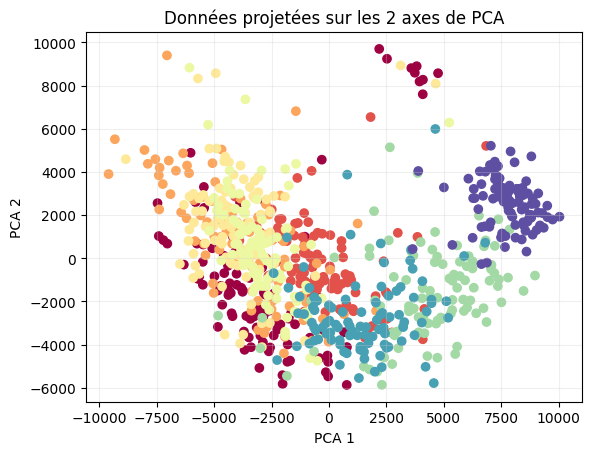

La part de variance expliquée est 0.9


In [101]:
pca = PCA(n_components = 0.9) # on fixe le seuil minimum de la part de la variance expliquée par le PCA
data_2D = pca.fit_transform(data)

fig = plt.figure()

ax = fig.add_subplot(111)
ax.scatter(data_2D[:, 0], data_2D[:, 1], c = target, cmap=plt.cm.Spectral)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')

ax.set_title("Données projetées sur les 2 axes de PCA")
plt.show();

print("La part de variance expliquée est", round(pca.explained_variance_ratio_.sum(),2))

In [102]:
print("Nombre de composantes retenues :", pca.n_components_)

Nombre de composantes retenues : 275


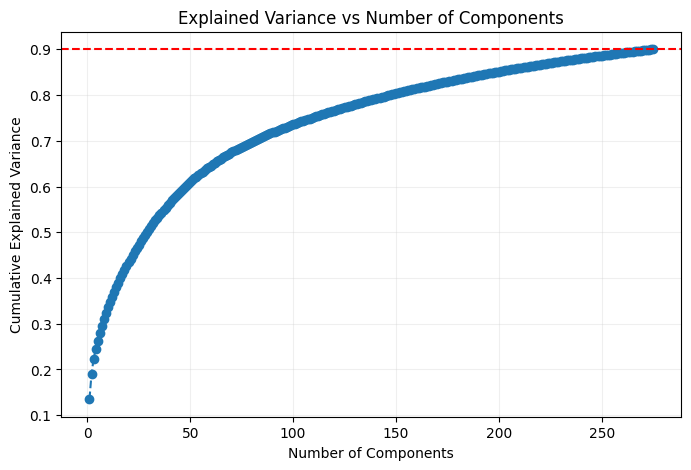

In [103]:
explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()

## Résultats

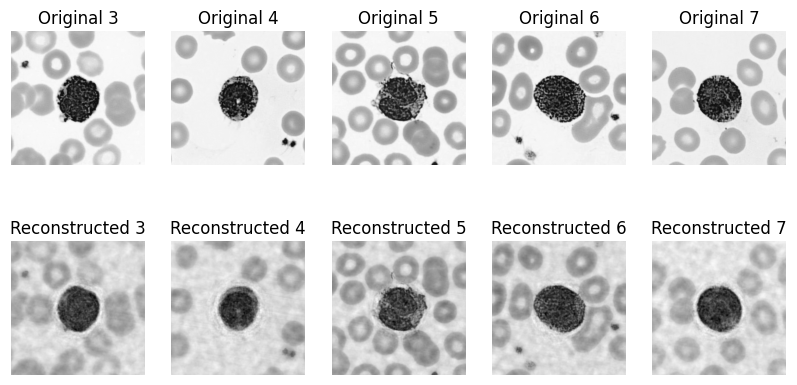

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

start_idx = 3
end_idx = 8
n_samples = end_idx - start_idx 
data_np = data.to_numpy()
reconstructed_data = pca.inverse_transform(data_2D)
IMAGE_HEIGHT = IMAGE_WIDTH = int(np.sqrt(data.shape[1]))

fig, axes = plt.subplots(2, n_samples, figsize=(10, 5))

for idx, i in enumerate(range(start_idx, end_idx)):  
    original_image = data_np[i].reshape(IMAGE_HEIGHT, IMAGE_WIDTH)  
    reconstructed_image = reconstructed_data[i].reshape(IMAGE_HEIGHT, IMAGE_WIDTH)  

    axes[0, idx].imshow(original_image, cmap='gray')  
    axes[0, idx].axis('off')
    axes[0, idx].set_title(f"Original {i}")

    axes[1, idx].imshow(reconstructed_image, cmap='gray') 
    axes[1, idx].axis('off')
    axes[1, idx].set_title(f"Reconstructed {i}")

plt.show()
